# XGBoost temp_mean / dc1_capafit process-control simulation

This notebook reproduces the same train/valid/test split used in `modeling_optimization.ipynb`, retrains the tuned XGBoost model from the saved tuning-result CSV, and simulates how predicted defect risk changes when `temp_mean` and/or `dc1_capafit` are generated from narrowed target-range process distributions.

Simulation cases use the full reproduced test set, without down-sampling:

- A: original full test set
- B-temp: same rows, only `temp_mean` regenerated in the 25.7-29.9 Celsius target range
- B-capa: same rows, only `dc1_capafit` regenerated in the 529-543 mAh target range
- B-both: same rows, both variables regenerated, preserving correlation when correlation is material

In [37]:
from pathlib import Path
import importlib.util
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, confusion_matrix

if importlib.util.find_spec('xgboost') is None:
    raise ImportError('Run this notebook in the same environment used for modeling_optimization.ipynb; xgboost is required.')

from xgboost import XGBClassifier
from IPython.display import Markdown, display

ROOT = Path.cwd()
DATA_DIR = ROOT / 'processed_data'
MODEL_OUT_DIR = ROOT / 'outputs_processed' / 'modeling'
SIM_OUT_DIR = ROOT / 'outputs_processed' / 'simulation'
SIM_OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_COL = 'judge'
TEMP_COL = 'temp_mean'
CAPA_COL = 'dc1_capafit'

SIM_SEED = RANDOM_STATE + 1000

TEMP_RANGE_C = (25.7, 29.9)
CAPA_RANGE = (529.0, 543.0)
SIGMA_DIVISOR = 6.0
CAPA_AS_INTEGER = False
CORR_THRESHOLD = 0.4

## 1. Load data and reproduce the original split

Use the same tree feature set and stratified split logic as `modeling_optimization.ipynb`.


In [38]:
df_final = pd.read_csv(DATA_DIR / 'df_final.csv')
tree_cols = pd.read_csv(DATA_DIR / 'tree_cols.csv').iloc[:, 0].dropna().tolist()

required_cols = {TARGET_COL, TEMP_COL, CAPA_COL}
missing_required = required_cols - set(df_final.columns)
if missing_required:
    raise ValueError(f'Missing required columns in df_final.csv: {missing_required}')

missing_tree_cols = set(tree_cols) - set(df_final.columns)
if missing_tree_cols:
    raise ValueError(f'tree_cols.csv contains columns not found in df_final.csv: {list(missing_tree_cols)[:10]}')

if TEMP_COL not in tree_cols or CAPA_COL not in tree_cols:
    raise ValueError(f'{TEMP_COL} and {CAPA_COL} must both be included in tree_cols.')

y = df_final[TARGET_COL].astype(int).copy()
X_tree_raw = df_final[tree_cols].replace([np.inf, -np.inf], np.nan).copy()

all_missing_cols = X_tree_raw.columns[X_tree_raw.isna().all()].tolist()
X_tree_for_impute = X_tree_raw.drop(columns=all_missing_cols)
imputer = SimpleImputer(strategy='median')
X_tree = pd.DataFrame(
    imputer.fit_transform(X_tree_for_impute),
    columns=X_tree_for_impute.columns,
    index=X_tree_for_impute.index,
)

idx_train_valid, idx_test = train_test_split(
    y.index,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)
idx_train, idx_valid = train_test_split(
    idx_train_valid,
    test_size=0.25,
    stratify=y.loc[idx_train_valid],
    random_state=RANDOM_STATE,
)

X_train_xgb, y_train_xgb = X_tree.loc[idx_train], y.loc[idx_train]
X_valid_xgb, y_valid_xgb = X_tree.loc[idx_valid], y.loc[idx_valid]
X_test_xgb, y_test_xgb = X_tree.loc[idx_test], y.loc[idx_test]

split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(idx_train), 'defects': int(y.loc[idx_train].sum()), 'defect_rate': y.loc[idx_train].mean()},
    {'split': 'valid', 'rows': len(idx_valid), 'defects': int(y.loc[idx_valid].sum()), 'defect_rate': y.loc[idx_valid].mean()},
    {'split': 'test', 'rows': len(idx_test), 'defects': int(y.loc[idx_test].sum()), 'defect_rate': y.loc[idx_test].mean()},
])

display(split_summary)
print(f'X_train={X_train_xgb.shape}, X_valid={X_valid_xgb.shape}, X_test={X_test_xgb.shape}')
if all_missing_cols:
    print('Dropped all-missing columns:', all_missing_cols)

,split,rows,defects,defect_rate
0,train,23157,731,0.031567
1,valid,7719,243,0.031481
2,test,7719,244,0.031610


X_train=(23157, 134), X_valid=(7719, 134), X_test=(7719, 134)


## 2. Retrain the tuned XGBoost model

The trained model object is not assumed to be saved. Instead, this notebook reads the best parameter row from `xgboost_tuning_results.csv`, retrains XGBoost on the reproduced train split, and recomputes the operating threshold on the reproduced validation split before running the simulation.


In [39]:
def find_best_threshold(y_true, score):
    precision, recall, thresholds = precision_recall_curve(y_true, score)
    if len(thresholds) == 0:
        return 0.5
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[int(np.nanargmax(f1))])


def basic_metric_row(case, y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    return {
        'case': case,
        'n': len(y_true),
        'actual_defect_rate': float(np.mean(y_true)),
        'predicted_defect_rate': float(np.mean(pred)),
        'predicted_good_rate': float(1.0 - np.mean(pred)),
        'mean_defect_probability': float(np.mean(score)),
        'tn': int(cm[0, 0]),
        'fp': int(cm[0, 1]),
        'fn': int(cm[1, 0]),
        'tp': int(cm[1, 1]),
    }


tuning_path = MODEL_OUT_DIR / 'xgboost_tuning_results.csv'
if not tuning_path.exists():
    raise FileNotFoundError(f'Missing tuning result file: {tuning_path}')

xgb_tuning_results = pd.read_csv(tuning_path, encoding='utf-8-sig')
required_metric_cols = ['valid_pr_auc', 'valid_f1']
missing_metric_cols = [col for col in required_metric_cols if col not in xgb_tuning_results.columns]
if missing_metric_cols:
    raise ValueError(f'xgboost_tuning_results.csv is missing required columns: {missing_metric_cols}')

valid_xgb_results = xgb_tuning_results.dropna(subset=required_metric_cols).copy()
valid_xgb_results = valid_xgb_results.sort_values(['valid_pr_auc', 'valid_f1'], ascending=False)
if len(valid_xgb_results) == 0:
    raise ValueError('No successful XGBoost tuning rows found in xgboost_tuning_results.csv')

best_row = valid_xgb_results.iloc[0]
best_xgb_name = best_row.get('model', 'XGBoost_tuned_best')

param_cols = [
    'n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree',
    'min_child_weight', 'gamma', 'reg_alpha', 'reg_lambda', 'scale_pos_weight'
]
missing_param_cols = [col for col in param_cols if col not in valid_xgb_results.columns]
if missing_param_cols:
    raise ValueError(f'xgboost_tuning_results.csv is missing parameter columns: {missing_param_cols}')

best_params = {col: pd.to_numeric(best_row[col]) for col in param_cols}
for int_col in ['n_estimators', 'max_depth', 'min_child_weight']:
    best_params[int_col] = int(best_params[int_col])
for float_col in sorted(set(param_cols) - {'n_estimators', 'max_depth', 'min_child_weight'}):
    best_params[float_col] = float(best_params[float_col])

best_xgb_model = XGBClassifier(
    **best_params,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
)

best_xgb_model.fit(X_train_xgb, y_train_xgb)
valid_score = best_xgb_model.predict_proba(X_valid_xgb)[:, 1]
test_score = best_xgb_model.predict_proba(X_test_xgb)[:, 1]

# New GridSearchCV output stores params and validation metrics, not the threshold.
# Recompute the operating threshold on the reproduced validation split for this notebook.
best_xgb_threshold = find_best_threshold(y_valid_xgb, valid_score)
threshold_from_csv = np.nan
if 'valid_threshold' in best_row.index and pd.notna(best_row['valid_threshold']):
    threshold_from_csv = float(best_row['valid_threshold'])

full_test_metrics = basic_metric_row('full_test', y_test_xgb.to_numpy(), test_score, best_xgb_threshold)
model_check = pd.DataFrame([{
    'best_model': best_xgb_name,
    'candidate_id': best_row.get('candidate_id', np.nan),
    'valid_pr_auc_from_csv': float(best_row['valid_pr_auc']),
    'valid_f1_from_csv': float(best_row['valid_f1']),
    'threshold_source': 'recomputed_from_validation_scores',
    'threshold_from_csv_if_available': threshold_from_csv,
    'best_xgb_threshold': best_xgb_threshold,
    'full_test_predicted_defect_rate': full_test_metrics['predicted_defect_rate'],
    'full_test_mean_defect_probability': float(np.mean(test_score)),
    **best_params,
}])

display(model_check)


,best_model,candidate_id,valid_pr_auc_from_csv,valid_f1_from_csv,threshold_source,threshold_from_csv_if_available,best_xgb_threshold,full_test_predicted_defect_rate,full_test_mean_defect_probability,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,reg_lambda,scale_pos_weight
0,XGBoost_grid_095,95,0.816783,0.761905,recomputed_from_validation_scores,NaN,0.410115,0.037181,0.036355,1000,6,0.03,0.8,0.8,1,0.0,0.0,1.0,30.678523


## 3. Define target distributions and correlation rule

The target distribution is a truncated normal centered at the target-range midpoint. The range width is treated as approximately six standard deviations. If the observed test-set correlation between `temp_mean` and `dc1_capafit` is material, the B-both scenario uses correlated bivariate generation.


In [40]:
def detect_temp_scale(series):
    return 10.0 if float(np.nanmedian(series)) > 100 else 1.0


temp_scale = detect_temp_scale(X_test_xgb[TEMP_COL])
temp_range_model = (TEMP_RANGE_C[0] * temp_scale, TEMP_RANGE_C[1] * temp_scale)

target_specs = {
    TEMP_COL: {
        'low': temp_range_model[0],
        'high': temp_range_model[1],
        'mean': np.mean(temp_range_model),
        'sd': (temp_range_model[1] - temp_range_model[0]) / SIGMA_DIVISOR,
        'display_low': TEMP_RANGE_C[0],
        'display_high': TEMP_RANGE_C[1],
        'display_mean': np.mean(TEMP_RANGE_C),
        'display_sd': (TEMP_RANGE_C[1] - TEMP_RANGE_C[0]) / SIGMA_DIVISOR,
        'unit': 'Celsius',
        'scale': temp_scale,
    },
    CAPA_COL: {
        'low': CAPA_RANGE[0],
        'high': CAPA_RANGE[1],
        'mean': np.mean(CAPA_RANGE),
        'sd': (CAPA_RANGE[1] - CAPA_RANGE[0]) / SIGMA_DIVISOR,
        'display_low': CAPA_RANGE[0],
        'display_high': CAPA_RANGE[1],
        'display_mean': np.mean(CAPA_RANGE),
        'display_sd': (CAPA_RANGE[1] - CAPA_RANGE[0]) / SIGMA_DIVISOR,
        'unit': 'mAh',
        'scale': 1.0,
    },
}

target_df = pd.DataFrame([{'column': col, **spec} for col, spec in target_specs.items()])
target_df = target_df[['column', 'display_low', 'display_high', 'display_mean', 'display_sd', 'unit', 'low', 'high', 'mean', 'sd', 'scale']]

corr_full_test = X_test_xgb[[TEMP_COL, CAPA_COL]].corr(method='pearson').iloc[0, 1]
spearman_full_test = X_test_xgb[[TEMP_COL, CAPA_COL]].corr(method='spearman').iloc[0, 1]
corr_decision_value = np.nanmax(np.abs([corr_full_test, spearman_full_test]))
use_correlated_both = bool(corr_decision_value >= CORR_THRESHOLD)
rho_for_generation = 0.0 if np.isnan(corr_full_test) else float(np.clip(corr_full_test, -0.95, 0.95))

corr_summary = pd.DataFrame([{
    'basis': 'full_test_set',
    'pearson_corr': corr_full_test,
    'spearman_corr': spearman_full_test,
    'corr_threshold': CORR_THRESHOLD,
    'B_both_generation_mode': 'correlated_bivariate_truncated_normal' if use_correlated_both else 'independent_truncated_normal',
    'rho_for_B_both': rho_for_generation if use_correlated_both else 0.0,
}])

display(target_df)
display(corr_summary)

,column,display_low,display_high,display_mean,display_sd,unit,low,high,mean,sd,scale
0,temp_mean,25.7,29.9,27.8,0.700000,Celsius,257.0,299.0,278.0,7.000000,10.0
1,dc1_capafit,529.0,543.0,536.0,2.333333,mAh,529.0,543.0,536.0,2.333333,1.0


,basis,pearson_corr,spearman_corr,corr_threshold,B_both_generation_mode,rho_for_B_both
0,full_test_set,-0.977638,-0.977274,0.4,correlated_bivariate_truncated_normal,-0.95


## 4. Sampling helpers

These helpers generate target-range values and create the B scenario matrices from each sampled A group.


In [41]:
def sample_truncated_normal(rng, mean, sd, low, high, size, integer=False):
    values = rng.normal(loc=mean, scale=sd, size=size)
    invalid = (values < low) | (values > high)
    attempts = 0
    while invalid.any() and attempts < 200:
        values[invalid] = rng.normal(loc=mean, scale=sd, size=int(invalid.sum()))
        invalid = (values < low) | (values > high)
        attempts += 1
    values = np.clip(values, low, high)
    if integer:
        values = np.rint(values)
        values = np.clip(values, low, high)
    return values


def sample_bivariate_truncated_normal(rng, specs, rho, size, capa_integer=True):
    temp = specs[TEMP_COL]
    capa = specs[CAPA_COL]
    means = np.array([temp['mean'], capa['mean']], dtype=float)
    sds = np.array([temp['sd'], capa['sd']], dtype=float)
    corr = np.array([[1.0, rho], [rho, 1.0]], dtype=float)
    cov = np.outer(sds, sds) * corr
    lows = np.array([temp['low'], capa['low']], dtype=float)
    highs = np.array([temp['high'], capa['high']], dtype=float)

    accepted = []
    attempts = 0
    while sum(len(x) for x in accepted) < size and attempts < 500:
        need = size - sum(len(x) for x in accepted)
        cand = rng.multivariate_normal(means, cov, size=max(need * 3, 100))
        valid = ((cand >= lows) & (cand <= highs)).all(axis=1)
        if valid.any():
            accepted.append(cand[valid][:need])
        attempts += 1

    if accepted:
        out = np.vstack(accepted)[:size]
    else:
        out = rng.multivariate_normal(means, cov, size=size)

    out = np.clip(out, lows, highs)
    if capa_integer:
        out[:, 1] = np.rint(out[:, 1])
        out[:, 1] = np.clip(out[:, 1], capa['low'], capa['high'])
    return out[:, 0], out[:, 1]



def make_scenario_matrix(X_base, rng, case):
    X_sim = X_base.copy()
    if case == 'B_temp_only':
        spec = target_specs[TEMP_COL]
        X_sim[TEMP_COL] = sample_truncated_normal(
            rng, spec['mean'], spec['sd'], spec['low'], spec['high'], len(X_sim), integer=False
        )
    elif case == 'B_capa_only':
        spec = target_specs[CAPA_COL]
        X_sim[CAPA_COL] = sample_truncated_normal(
            rng, spec['mean'], spec['sd'], spec['low'], spec['high'], len(X_sim), integer=CAPA_AS_INTEGER
        )
    elif case == 'B_temp_and_capa':
        if use_correlated_both:
            temp_values, capa_values = sample_bivariate_truncated_normal(
                rng, target_specs, rho_for_generation, len(X_sim), capa_integer=CAPA_AS_INTEGER
            )
            X_sim[TEMP_COL] = temp_values
            X_sim[CAPA_COL] = capa_values
        else:
            temp_spec = target_specs[TEMP_COL]
            capa_spec = target_specs[CAPA_COL]
            X_sim[TEMP_COL] = sample_truncated_normal(
                rng, temp_spec['mean'], temp_spec['sd'], temp_spec['low'], temp_spec['high'], len(X_sim), integer=False
            )
            X_sim[CAPA_COL] = sample_truncated_normal(
                rng, capa_spec['mean'], capa_spec['sd'], capa_spec['low'], capa_spec['high'], len(X_sim), integer=CAPA_AS_INTEGER
            )
    else:
        raise ValueError(f'unknown case: {case}')
    return X_sim

## 5. Run full-test-set simulation

Each scenario uses every row in the reproduced test set. All features remain fixed except the process variable(s) regenerated for each B case.

In [42]:
SCENARIO_LABELS = {
    'A_actual': 'A: original full test set',
    'B_temp_only': 'B-temp: temp in target range',
    'B_capa_only': 'B-capa: capacity in target range',
    'B_temp_and_capa': 'B-both: temp + capacity in target range',
}

SCENARIO_LABELS_KR = {
    'A_actual': 'A: 기존 테스트셋 전체',
    'B_temp_only': 'B-temp: 온도만 목표범위',
    'B_capa_only': 'B-capa: 용량만 목표범위',
    'B_temp_and_capa': 'B-both: 온도+용량 목표범위',
}

scenario_cases = ['B_temp_only', 'B_capa_only', 'B_temp_and_capa']
case_order = ['A_actual'] + scenario_cases

rng = np.random.default_rng(SIM_SEED)
X_a = X_test_xgb.copy()
y_a = y_test_xgb.to_numpy()

scenario_matrices = {'A_actual': X_a}
scenario_scores = {'A_actual': best_xgb_model.predict_proba(X_a)[:, 1]}

baseline_row = basic_metric_row('A_actual', y_a, scenario_scores['A_actual'], best_xgb_threshold)
baseline_row.update({
    'seed': SIM_SEED,
    'case_label': SCENARIO_LABELS['A_actual'],
    'baseline_predicted_defect_rate': baseline_row['predicted_defect_rate'],
    'baseline_predicted_good_rate': baseline_row['predicted_good_rate'],
    'baseline_mean_defect_probability': baseline_row['mean_defect_probability'],
    'predicted_defect_rate_improvement_p': 0.0,
    'predicted_good_rate_increase_p': 0.0,
    'mean_defect_probability_improvement_p': 0.0,
})

rows = [baseline_row]
detail_rows = []

for case in scenario_cases:
    X_b = make_scenario_matrix(X_a, rng, case)
    score = best_xgb_model.predict_proba(X_b)[:, 1]
    row = basic_metric_row(case, y_a, score, best_xgb_threshold)
    row.update({
        'seed': SIM_SEED,
        'case_label': SCENARIO_LABELS[case],
        'baseline_predicted_defect_rate': baseline_row['predicted_defect_rate'],
        'baseline_predicted_good_rate': baseline_row['predicted_good_rate'],
        'baseline_mean_defect_probability': baseline_row['mean_defect_probability'],
        'predicted_defect_rate_improvement_p': baseline_row['predicted_defect_rate'] - row['predicted_defect_rate'],
        'predicted_good_rate_increase_p': row['predicted_good_rate'] - baseline_row['predicted_good_rate'],
        'mean_defect_probability_improvement_p': baseline_row['mean_defect_probability'] - row['mean_defect_probability'],
    })
    rows.append(row)
    scenario_matrices[case] = X_b
    scenario_scores[case] = score

    detail_rows.append(pd.DataFrame({
        'row_index': X_a.index,
        'actual_judge': y_a,
        'case': case,
        'baseline_score': scenario_scores['A_actual'],
        'scenario_score': score,
        'baseline_temp_mean_C': X_a[TEMP_COL].to_numpy() / temp_scale,
        'scenario_temp_mean_C': X_b[TEMP_COL].to_numpy() / temp_scale,
        'baseline_dc1_capafit': X_a[CAPA_COL].to_numpy(),
        'scenario_dc1_capafit': X_b[CAPA_COL].to_numpy(),
        'score_delta': score - scenario_scores['A_actual'],
    }))

sim_df = pd.DataFrame(rows)
detail_df = pd.concat(detail_rows, ignore_index=True) if detail_rows else pd.DataFrame()

sim_path = SIM_OUT_DIR / 'xgboost_temp_capa_full_test_distribution_simulation.csv'
detail_path = SIM_OUT_DIR / 'xgboost_temp_capa_full_test_distribution_detail.csv'
sim_df.to_csv(sim_path, index=False, encoding='utf-8-sig')
detail_df.to_csv(detail_path, index=False, encoding='utf-8-sig')

print('saved:', sim_path)
print('saved:', detail_path)
display(sim_df[['case', 'n', 'actual_defect_rate', 'predicted_defect_rate', 'mean_defect_probability', 'tn', 'fp', 'fn', 'tp']])

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/simulation/xgboost_temp_capa_full_test_distribution_simulation.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/simulation/xgboost_temp_capa_full_test_distribution_detail.csv


,case,n,actual_defect_rate,predicted_defect_rate,mean_defect_probability,tn,fp,fn,tp
0,A_actual,7719,0.03161,0.037181,0.036355,7393,82,39,205
1,B_temp_only,7719,0.03161,0.033683,0.030571,7403,72,56,188
2,B_capa_only,7719,0.03161,0.016842,0.017505,7420,55,169,75
3,B_temp_and_capa,7719,0.03161,0.015417,0.014905,7425,50,175,69


## 6. Summarize case-level defect rates

Positive effect values mean improvement: defect-rate and defect-probability reduction, or good-rate increase.

In [43]:
def summarize_effects(sim_df):
    baseline = sim_df.loc[sim_df['case'] == 'A_actual'].iloc[0]
    rows = []
    for _, row in sim_df.set_index('case').loc[case_order].reset_index().iterrows():
        rows.append({
            'case': SCENARIO_LABELS_KR.get(row['case'], row['case']),
            'n': int(row['n']),
            '실제 불량률(%)': row['actual_defect_rate'] * 100,
            '예측 불량률(%)': row['predicted_defect_rate'] * 100,
            '평균 불량확률(%)': row['mean_defect_probability'] * 100,
            '예측 양품률(%)': row['predicted_good_rate'] * 100,
            'A 대비 예측 불량률 개선(%p)': (baseline['predicted_defect_rate'] - row['predicted_defect_rate']) * 100,
            'A 대비 평균 불량확률 개선(%p)': (baseline['mean_defect_probability'] - row['mean_defect_probability']) * 100,
            'tn': int(row['tn']),
            'fp': int(row['fp']),
            'fn': int(row['fn']),
            'tp': int(row['tp']),
        })
    return pd.DataFrame(rows)

summary_df = summarize_effects(sim_df)
summary_path = SIM_OUT_DIR / 'xgboost_temp_capa_full_test_distribution_kpi_summary.csv'
summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
print('saved:', summary_path)
display(summary_df)

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/simulation/xgboost_temp_capa_full_test_distribution_kpi_summary.csv


,case,n,실제 불량률(%),예측 불량률(%),평균 불량확률(%),예측 양품률(%),A 대비 예측 불량률 개선(%p),A 대비 평균 불량확률 개선(%p),tn,fp,fn,tp
0,A: 기존 테스트셋 전체,7719,3.161031,3.718098,3.635535,96.281902,0.000000,0.000000,7393,82,39,205
1,B-temp: 온도만 목표범위,7719,3.161031,3.368312,3.057101,96.631688,0.349786,0.578435,7403,72,56,188
2,B-capa: 용량만 목표범위,7719,3.161031,1.684156,1.750499,98.315844,2.033942,1.885036,7420,55,169,75
3,B-both: 온도+용량 목표범위,7719,3.161031,1.541650,1.490523,98.458350,2.176448,2.145012,7425,50,175,69


## 7. Presentation visuals

The distribution overlay shows only the original full test set and the matching B scenario: Original vs B-temp for `temp_mean`, and Original vs B-capa for `dc1_capafit`. Each plot includes mean and 3-sigma markers. All plot labels are in English.

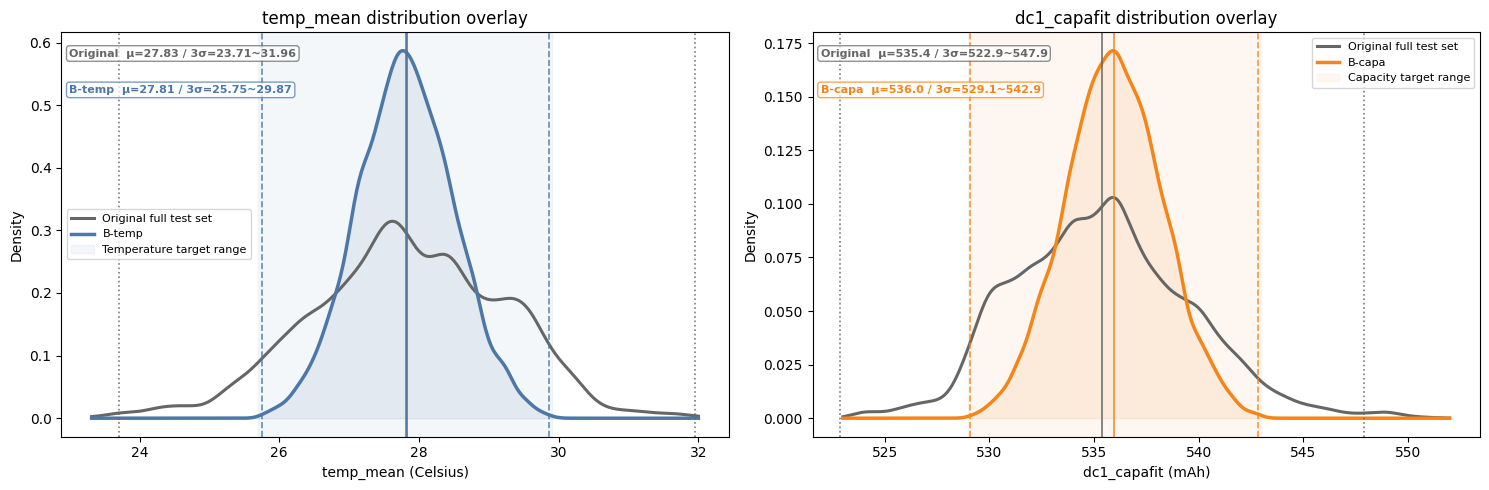

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/simulation/xgboost_temp_capa_full_test_distribution_overlay_3sigma.png
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/simulation/xgboost_temp_capa_full_test_distribution_3sigma_summary.csv


,variable,distribution,mean,sigma,minus_3sigma,plus_3sigma
0,temp_mean,Original full test set,27.831353,1.374716,23.707204,31.955502
1,temp_mean,B-temp,27.809179,0.685535,25.752574,29.865784
2,dc1_capafit,Original full test set,535.392279,4.174358,522.869205,547.915352
3,dc1_capafit,B-capa,535.954712,2.299334,529.056711,542.852714


,case,n,예측 불량률(%),평균 불량확률(%),A 대비 예측 불량률 개선(%p),A 대비 평균 불량확률 개선(%p)
0,A: 기존 테스트셋 전체,7719,3.718098,3.635535,0.000000,0.000000
1,B-temp: 온도만 목표범위,7719,3.368312,3.057101,0.349786,0.578435
2,B-capa: 용량만 목표범위,7719,1.684156,1.750499,2.033942,1.885036
3,B-both: 온도+용량 목표범위,7719,1.541650,1.490523,2.176448,2.145012


In [44]:
def kde_curve(values, grid, bandwidth=None):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    grid = np.asarray(grid, dtype=float)
    if len(values) == 0:
        return np.zeros_like(grid)
    if bandwidth is None:
        std = np.std(values, ddof=1) if len(values) > 1 else 0.0
        iqr = np.subtract(*np.percentile(values, [75, 25])) if len(values) > 1 else 0.0
        sigma = min(std, iqr / 1.349) if std > 0 and iqr > 0 else max(std, iqr / 1.349, 1e-6)
        bandwidth = 0.9 * sigma * (len(values) ** (-1 / 5))
        if not np.isfinite(bandwidth) or bandwidth <= 0:
            bandwidth = max((grid.max() - grid.min()) / 50, 1e-6)
    z = (grid[:, None] - values[None, :]) / bandwidth
    return np.exp(-0.5 * z * z).mean(axis=1) / (bandwidth * np.sqrt(2 * np.pi))


def plot_density(ax, values, grid, label, color, linewidth=2.0, linestyle='-', alpha_fill=0.0):
    density = kde_curve(values, grid)
    ax.plot(grid, density, color=color, linewidth=linewidth, linestyle=linestyle, label=label)
    if alpha_fill > 0:
        ax.fill_between(grid, density, color=color, alpha=alpha_fill)


def add_three_sigma_markers(ax, values, color, label, y_axis_slot, linestyle=':', value_digits=2):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    mu = float(np.mean(values))
    sigma = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
    low = mu - 3 * sigma
    high = mu + 3 * sigma

    # Keep mean and 3-sigma lines out of the legend; annotate them beside the y-axis instead.
    ax.axvline(mu, color=color, linestyle='-', linewidth=1.3, alpha=0.85, label='_nolegend_')
    ax.axvline(low, color=color, linestyle=linestyle, linewidth=1.2, alpha=0.85, label='_nolegend_')
    ax.axvline(high, color=color, linestyle=linestyle, linewidth=1.2, alpha=0.85, label='_nolegend_')

    axis_text = f'{label}  μ={mu:.{value_digits}f} / 3σ={low:.{value_digits}f}~{high:.{value_digits}f}'
    ax.text(
        0.012,
        y_axis_slot,
        axis_text,
        transform=ax.transAxes,
        color=color,
        ha='left',
        va='top',
        fontsize=8,
        fontweight='bold',
        bbox={'facecolor': 'white', 'edgecolor': color, 'alpha': 0.72, 'boxstyle': 'round,pad=0.25'},
    )
    return {'mean': mu, 'sigma': sigma, 'minus_3sigma': low, 'plus_3sigma': high}


original_test_temp_c = X_test_xgb[TEMP_COL] / temp_scale
original_test_capa = X_test_xgb[CAPA_COL]
b_temp_c = scenario_matrices['B_temp_only'][TEMP_COL] / temp_scale
b_capa = scenario_matrices['B_capa_only'][CAPA_COL]

temp_grid = np.linspace(
    min(original_test_temp_c.min(), b_temp_c.min(), TEMP_RANGE_C[0] - 2),
    max(original_test_temp_c.max(), b_temp_c.max(), TEMP_RANGE_C[1] + 2),
    500,
)
capa_grid = np.linspace(
    min(original_test_capa.min(), b_capa.min(), CAPA_RANGE[0]) - 1,
    max(original_test_capa.max(), b_capa.max(), CAPA_RANGE[1]) + 1,
    500,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_density(axes[0], original_test_temp_c, temp_grid, 'Original full test set', '#666666', linewidth=2.2)
plot_density(axes[0], b_temp_c, temp_grid, 'B-temp', '#4C78A8', linewidth=2.5, alpha_fill=0.10)
axes[0].axvspan(TEMP_RANGE_C[0], TEMP_RANGE_C[1], color='#4C78A8', alpha=0.06, label='Temperature target range')
temp_sigma_original = add_three_sigma_markers(axes[0], original_test_temp_c, '#666666', 'Original', 0.96, value_digits=2)
temp_sigma_b = add_three_sigma_markers(axes[0], b_temp_c, '#4C78A8', 'B-temp', 0.87, linestyle='--', value_digits=2)
axes[0].set_title('temp_mean distribution overlay')
axes[0].set_xlabel('temp_mean (Celsius)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

plot_density(axes[1], original_test_capa, capa_grid, 'Original full test set', '#666666', linewidth=2.2)
plot_density(axes[1], b_capa, capa_grid, 'B-capa', '#F58518', linewidth=2.5, alpha_fill=0.10)
axes[1].axvspan(CAPA_RANGE[0], CAPA_RANGE[1], color='#F58518', alpha=0.06, label='Capacity target range')
capa_sigma_original = add_three_sigma_markers(axes[1], original_test_capa, '#666666', 'Original', 0.96, value_digits=1)
capa_sigma_b = add_three_sigma_markers(axes[1], b_capa, '#F58518', 'B-capa', 0.87, linestyle='--', value_digits=1)
axes[1].set_title('dc1_capafit distribution overlay')
axes[1].set_xlabel('dc1_capafit (mAh)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

fig.tight_layout()
overlay_path = SIM_OUT_DIR / 'xgboost_temp_capa_full_test_distribution_overlay_3sigma.png'
fig.savefig(overlay_path, dpi=160, bbox_inches='tight')
plt.show()
print('saved:', overlay_path)

sigma_summary = pd.DataFrame([
    {'variable': 'temp_mean', 'distribution': 'Original full test set', **temp_sigma_original},
    {'variable': 'temp_mean', 'distribution': 'B-temp', **temp_sigma_b},
    {'variable': 'dc1_capafit', 'distribution': 'Original full test set', **capa_sigma_original},
    {'variable': 'dc1_capafit', 'distribution': 'B-capa', **capa_sigma_b},
])
sigma_path = SIM_OUT_DIR / 'xgboost_temp_capa_full_test_distribution_3sigma_summary.csv'
sigma_summary.to_csv(sigma_path, index=False, encoding='utf-8-sig')
print('saved:', sigma_path)
display(sigma_summary)

case_rate_table = summary_df[[
    'case', 'n', '예측 불량률(%)', '평균 불량확률(%)',
    'A 대비 예측 불량률 개선(%p)', 'A 대비 평균 불량확률 개선(%p)'
]].copy()
display(case_rate_table)

## 8. Final Markdown KPI table

The last cell prints and saves a Markdown table for presentation/report use.


In [45]:
def format_float(x, digits=3):
    if pd.isna(x):
        return ''
    return f'{x:.{digits}f}'


def dataframe_to_markdown(df):
    headers = list(df.columns)
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    for _, row in df.iterrows():
        lines.append('| ' + ' | '.join(str(row[col]) for col in headers) + ' |')
    return '\n'.join(lines)


final_table = summary_df[[
    'case', 'n', '예측 불량률(%)', '평균 불량확률(%)', '예측 양품률(%)',
    'A 대비 예측 불량률 개선(%p)', 'A 대비 평균 불량확률 개선(%p)'
]].copy()

for col in ['예측 불량률(%)', '평균 불량확률(%)', '예측 양품률(%)', 'A 대비 예측 불량률 개선(%p)', 'A 대비 평균 불량확률 개선(%p)']:
    final_table[col] = final_table[col].map(lambda x: format_float(x, 3))

slide_takeaway = '테스트셋 전체 기준으로 온도와 용량 산포를 목표 범위의 3σ 수준으로 좁혔을 때, XGBoost가 예측한 case별 불량률 변화를 한눈에 비교할 수 있습니다.'

markdown_text = (
    '### XGBoost 공정 산포 축소 시뮬레이션 KPI 요약\n\n'
    f'- A 기준: 기존 test split 전체 {len(X_test_xgb):,}건\n'
    f'- 시뮬레이션 seed: {SIM_SEED}\n'
    f'- 온도 목표 범위: {TEMP_RANGE_C[0]}℃ ~ {TEMP_RANGE_C[1]}℃\n'
    f'- 용량 목표 범위: {CAPA_RANGE[0]:.0f}mAh ~ {CAPA_RANGE[1]:.0f}mAh\n'
    f'- B-both 생성 방식: {corr_summary.loc[0, "B_both_generation_mode"]}\n\n'
    + dataframe_to_markdown(final_table)
    + '\n\n**슬라이드 하단 문장**  \n'
    + slide_takeaway
)

display(Markdown(markdown_text))

md_path = SIM_OUT_DIR / 'xgboost_temp_capa_full_test_distribution_kpi_summary.md'
md_path.write_text(markdown_text, encoding='utf-8')
print('saved:', md_path)
print('slide_takeaway:', slide_takeaway)

### XGBoost 공정 산포 축소 시뮬레이션 KPI 요약

- A 기준: 기존 test split 전체 7,719건
- 시뮬레이션 seed: 1042
- 온도 목표 범위: 25.7℃ ~ 29.9℃
- 용량 목표 범위: 529mAh ~ 543mAh
- B-both 생성 방식: correlated_bivariate_truncated_normal

| case | n | 예측 불량률(%) | 평균 불량확률(%) | 예측 양품률(%) | A 대비 예측 불량률 개선(%p) | A 대비 평균 불량확률 개선(%p) |
| --- | --- | --- | --- | --- | --- | --- |
| A: 기존 테스트셋 전체 | 7719 | 3.718 | 3.636 | 96.282 | 0.000 | 0.000 |
| B-temp: 온도만 목표범위 | 7719 | 3.368 | 3.057 | 96.632 | 0.350 | 0.578 |
| B-capa: 용량만 목표범위 | 7719 | 1.684 | 1.750 | 98.316 | 2.034 | 1.885 |
| B-both: 온도+용량 목표범위 | 7719 | 1.542 | 1.491 | 98.458 | 2.176 | 2.145 |

**슬라이드 하단 문장**  
테스트셋 전체 기준으로 온도와 용량 산포를 목표 범위의 3σ 수준으로 좁혔을 때, XGBoost가 예측한 case별 불량률 변화를 한눈에 비교할 수 있습니다.

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/simulation/xgboost_temp_capa_full_test_distribution_kpi_summary.md
slide_takeaway: 테스트셋 전체 기준으로 온도와 용량 산포를 목표 범위의 3σ 수준으로 좁혔을 때, XGBoost가 예측한 case별 불량률 변화를 한눈에 비교할 수 있습니다.
